In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress
from scipy.spatial.distance import cdist
import warnings
import pickle as pkl
import os
warnings.simplefilter("ignore")

In [3]:
from mtu_utils import (
    get_inter_user_metrics,
    get_intra_user_metrics,
    get_sim_users_pairs,
)

In [4]:
from mtu_plots import graph_metrics_models_and_mtu

In [5]:
model_keys = [
    #"ideal",
    "content_5",
    #"content_10",
    #"pop",
    "mf",
    #"sf",
    #"random"
]

metric_list = [
    "interaction_history",
    "decisions",
    "utility_history",
    "trait_history",
    "rank_history",
    ]

feed_names = [
    "rand_feed",
    "pop_feed",
    "trend_feed",
    "new_feed",
    "social_feed",
    #"ideal_feed",
    #"any_feed",
    ]

In [6]:
# graphing
plt.style.use('seaborn-whitegrid')
plt.rcParams.update({'font.size': 14})
plotting_sigma = 0.1

rs_colors = {
    'content_5' : 'tab:green',
    #'content_10' : 'tab:orange',
    'pop' : 'tab:red',
    'sf' : 'tab:brown',
    'mf' : 'tab:purple',
    'ideal' : 'tab:blue',
    'random' : 'tab:pink'
}

feed_colors = {
    "rs_feed": "grey",
    "rand_feed": "magenta",
    "pop_feed": "red",
    "trend_feed": "orange",
    "new_feed": "purple",
    "social_feed": "saddlebrown",
}
indexable_feed_colors = np.array(list(feed_colors.values()))

# readable legend keys
model_to_readable = {
    "ideal": "Ideal",
    "content_5": "Content-based Filtering",
    #"content_10": "Content Filtering 10 Tags",
    "pop": "Popularity",
    "mf" : "Matrix Factorization",
    "sf": "Social Filtering", 
    "random": "Random"
}

feed_names_to_readable = {
    "rand_feed": "Random Feed",
    "pop_feed": "Popular Feed",
    "trend_feed": "Trending Feed",
    "new_feed": "News Feed",
    "social_feed": "Social Feed",
    #"ideal_feed": "Ideal",
    #"any_feed": "Any",
}

metric_names_to_readable = {
    "mean_util": "Mean Utility per Interaction",
    "inter": "Inter-user Diversity",
    "intra": "Intra-user Diversity",
    "homog": "General Homogenization",
    "sim_homog": "Similar Users Homogenization",
    "gini": "Gini Index",
    "cover": "Item Coverage",
    "choices": "Feed Choices of Users",
    "rs_util": "Mean Utility per RS choices",
    "rs_util_share": "Proportion of Utility comming from RS",
    "rs_influence": "RS Utility improvement"
}


In [7]:
results_file = "/home/salveal/data/salveal/results19"
inpi = 40
all_folder_paths = {feed_folder_path : [results_file + "/" + feed_folder_path + "/r" + str(i) for i in range(6)]
                    for feed_folder_path in feed_names}
all_results_to_readable = {feed: {all_folder_paths[feed][i]: str(20*i - int(i==5))+"%" 
                                for i in range(6)} 
                           for feed in feed_names}

In [8]:
all_final_results = dict()
all_item_attrs = dict()
for feed, folder_paths in all_folder_paths.items():
    final_results = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    for folder_path in folder_paths:
        filepath = os.path.join(folder_path, "sim_results.pkl")
        results = pkl.load(open(filepath, "rb"))
        for metric_name, v in results.items():
            for model_name, metric_vals in v.items():
                final_results[metric_name][model_name][folder_path] += np.array(metric_vals).tolist()
    all_final_results[feed] = final_results
    all_item_attrs[feed] = np.array(final_results['item_attrs']['all'][folder_paths[0]])

In [9]:
all_interactions = dict()
all_user_iter_attrs_ideals = dict()
for feed, folder_paths in all_folder_paths.items():
    interactions = dict()
    for mo in model_keys + ['ideal']:
        interactions[mo] = dict()
        folder_to_inspect = folder_paths #if mo != "content_reduced" else folder_paths_CBF
        for fo in folder_to_inspect:
            interactions[mo][fo] = np.array(all_final_results[feed]['interaction_history'][mo][fo]) #if mo != "content_reduced" else np.array(final_results_CBF['interaction_history'][mo][fo])
            interactions[mo][fo] = np.transpose(interactions[mo][fo].reshape(interactions[mo][fo].shape[:-1]), axes=[0,2,1])
    all_interactions[feed] = interactions
    # I suspect this last line is the same for all feeds but i'll need to test that
    all_user_iter_attrs_ideals[feed] = np.array([all_item_attrs[feed][i].T[interactions['ideal'][folder_paths[0]][i]] for i in range(interactions['ideal'][folder_paths[0]].shape[0])])

In [10]:
all_decisions = dict()
for feed, folder_paths in all_folder_paths.items():
    decisions = dict()
    for mo in model_keys:
        decisions[mo] = dict()
        folder_to_inspect = folder_paths #if mo != "content_reduced" else folder_paths_CBF
        for fo in folder_to_inspect:
            decisions[mo][fo] = np.array(all_final_results[feed]['decisions'][mo][fo]) #if mo != "content_reduced" else np.array(final_results_CBF['decisions'][mo][fo])
            decisions[mo][fo] = np.transpose(decisions[mo][fo], axes=[0,2,1])
    all_decisions[feed] = decisions

In [11]:
all_utilities = dict()
for feed, folder_paths in all_folder_paths.items():
    utilities = dict()
    for mo in model_keys:
        utilities[mo] = dict()
        folder_to_inspect = folder_paths #if mo != "content_reduced" else folder_paths_CBF
        for fo in folder_to_inspect:
            utilities[mo][fo] = np.array(all_final_results[feed]['utility_history'][mo][fo]) #if mo != "content_reduced" else np.array(final_results_CBF['utility_history'][mo][fo])
            utilities[mo][fo] = np.transpose(utilities[mo][fo], axes=[0,2,1])
    all_utilities[feed] = utilities

In [12]:
all_traits = dict()
for feed, folder_paths in all_folder_paths.items():
    traits = dict()
    for mo in model_keys:
        traits[mo] = dict()
        folder_to_inspect = folder_paths
        for fo in folder_to_inspect:
            traits[mo][fo] = np.array(all_final_results[feed]['trait_history'][mo][fo])
            traits[mo][fo] = np.transpose(traits[mo][fo], axes=[0,2,1,3])
    all_traits[feed] = traits

In [13]:
all_ranks = dict()
for feed, folder_paths in all_folder_paths.items():
    ranks = dict()
    for mo in model_keys:
        ranks[mo] = dict()
        folder_to_inspect = folder_paths
        for fo in folder_to_inspect:
            ranks[mo][fo] = np.array(all_final_results[feed]['rank_history'][mo][fo])
            ranks[mo][fo] = np.transpose(ranks[mo][fo], axes=[0,2,1])
    all_ranks[feed] = ranks

# Getting All Measurement Values

## Utility

In [14]:
all_tot_user_util = dict()
for feed, folder_paths in all_folder_paths.items():
    tot_user_util = dict()
    for mo in all_utilities[feed].keys():
        tot_user_util[mo] = dict()
        for fo in all_utilities[feed][mo].keys():
            tot_user_util[mo][fo] = []
            for i in range(all_utilities[feed][mo][fo].shape[0]):
                #re = []
                #re.append(all_utilities[feed][mo][fo][i].mean())
                tot_user_util[mo][fo].append(all_utilities[feed][mo][fo][i].mean())
            tot_user_util[mo][fo] = np.array(tot_user_util[mo][fo])
    all_tot_user_util[feed] = tot_user_util

## Choice Distribution

In [15]:
all_choices = dict()
for feed in feed_names:
    choices = dict()
    for mo in all_decisions[feed].keys():
        choices[mo] = dict()
        for fo in all_decisions[feed][mo].keys():
            choices[mo][fo] = []
            for i in range(all_decisions[feed][mo][fo].shape[0]):
                #re = []
                rs_choices_in_run = np.count_nonzero(all_decisions[feed][mo][fo][i] == 0)
                all_choices_in_run = all_decisions[feed][mo][fo].shape[1]*all_decisions[feed][mo][fo].shape[2]
                #print(rs_choices/all_choices)
                #re.append(rs_choices_in_run/all_choices_in_run)
                choices[mo][fo].append(rs_choices_in_run/all_choices_in_run)
            choices[mo][fo] = np.array(choices[mo][fo])
    all_choices[feed] = choices

In [16]:
choices[mo][fo]

array([0.04725, 0.034  , 0.05655, 0.04075, 0.0424 , 0.04125, 0.03055,
       0.0533 , 0.0516 , 0.0633 , 0.0615 , 0.0471 , 0.04725, 0.0596 ,
       0.08575, 0.04175, 0.0587 , 0.0426 , 0.0493 , 0.04045, 0.05365,
       0.02765, 0.04755, 0.0485 , 0.03635, 0.0555 , 0.0805 , 0.03625,
       0.0322 , 0.041  ])

## Diversity

In [17]:
all_inter_user_div = dict()
for feed, _ in all_folder_paths.items():
    inter_user_div = dict()
    for mo in all_interactions[feed].keys():
        inter_user_div[mo] = dict()
        for fo in all_interactions[feed][mo].keys():
            inter_user_div[mo][fo] = []
            for i in range(all_interactions[feed][mo][fo].shape[0]):
                re = []
                user_iter_attrs = all_item_attrs[feed][i].T[all_interactions[feed][mo][fo][i]]
                for j in range(user_iter_attrs.shape[1]):
                    mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
                    user_mean = mean_user_attrs.mean(axis=0)
                    distances = np.linalg.norm(mean_user_attrs - user_mean, axis=1)
                    variance = ((distances**2).sum())/distances.shape[0]
                    re.append(variance**0.5)
                inter_user_div[mo][fo].append(re)
            inter_user_div[mo][fo] = np.array(inter_user_div[mo][fo])
    all_inter_user_div[feed] = inter_user_div

In [18]:
all_intra_user_div = dict()
for feed, _ in all_folder_paths.items():
    intra_user_div = dict()
    for mo in all_interactions[feed].keys():
        intra_user_div[mo] = dict()
        for fo in all_interactions[feed][mo].keys():
            intra_user_div[mo][fo] = []
            for i in range(all_interactions[feed][mo][fo].shape[0]):
                re = []
                user_iter_attrs = all_item_attrs[feed][i].T[all_interactions[feed][mo][fo][i]]
                for j in range(user_iter_attrs.shape[1]-1, user_iter_attrs.shape[1]):
                    mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
                    diff_vectors = np.array([user_iter_attrs[k,:(j+1)] - mean_user_attrs[k] for k in range(user_iter_attrs.shape[0])])
                    distances = np.linalg.norm(diff_vectors, axis=2)
                    variances = ((distances**2).sum(axis=1))/distances.shape[1]
                    re.append((variances**0.5).mean())
                intra_user_div[mo][fo].append(re)
            intra_user_div[mo][fo] = np.array(intra_user_div[mo][fo])
    all_intra_user_div[feed] = intra_user_div

In [19]:
all_homog = dict()
for feed, _ in all_folder_paths.items():
    homog = dict()
    for mo in all_interactions[feed].keys():
        homog[mo] = dict()
        for fo in all_interactions[feed][mo].keys():
            homog[mo][fo] = (all_inter_user_div[feed][mo][fo]**2 + all_intra_user_div[feed][mo][fo]**2)**(-0.5)
    all_homog[feed] = homog

In [20]:
def compute_distance_matrix(set_A, set_B):
    d = set_A[:,np.newaxis,:] - set_B[np.newaxis,:,:]
    d = np.linalg.norm(d, axis=2)
    return d

In [ ]:
all_chamfer = dict()
for feed, _ in all_folder_paths.items():
    chamfer = dict()
    for mo in all_interactions[feed].keys():
        chamfer[mo] = dict()
        for fo in all_interactions[feed][mo].keys():
            chamfer[mo][fo] = []
            for i in range(all_interactions[feed][mo][fo].shape[0]):
                re = []
                user_iter_attrs = all_item_attrs[feed][i].T[all_interactions[feed][mo][fo][i]]
                for j in range(user_iter_attrs.shape[1]-1, user_iter_attrs.shape[1]): # sólo última iter pq se tarda mucho
                    mean_user_attrs = user_iter_attrs[:, :(j+1)].mean(axis=1)
                    nearest_users = get_sim_users_pairs(mean_user_attrs)

                    pairs_p_iter_attrs = user_iter_attrs[nearest_users]

                    # Initialize arrays to store distances
                    pair_inter_inter_d = np.zeros((pairs_p_iter_attrs.shape[0], j+1, j+1))
                    ideal_pair_inter_inter_d = np.zeros((pairs_p_iter_attrs.shape[0], j+1, j+1))

                    # Compute pairwise distances for each pair
                    for p in range(pairs_p_iter_attrs.shape[0]):
                        # Compute distances between pairs_p_iter_attrs[p, 0] and pairs_p_iter_attrs[p, 1]
                        pair_inter_inter_d[p] = cdist(pairs_p_iter_attrs[p, 0, :(j+1)], pairs_p_iter_attrs[p, 1, :(j+1)], metric='euclidean')

                        # Compute distances for the ideal pairs
                        ideal_pairs_p_iter_attrs = all_user_iter_attrs_ideals[feed][i, nearest_users]
                        ideal_pair_inter_inter_d[p] = cdist(ideal_pairs_p_iter_attrs[p, 0, :(j+1)], ideal_pairs_p_iter_attrs[p, 1, :(j+1)], metric='euclidean')

                    min_axis_0 = np.min(pair_inter_inter_d, axis=2)
                    min_axis_1 = np.min(pair_inter_inter_d, axis=1)
                    all_min_values = np.concatenate([min_axis_0.flatten(), min_axis_1.flatten()])
                    chamfer_iter = np.mean(all_min_values)

                    ideal_min_axis_0 = np.min(ideal_pair_inter_inter_d, axis=2)
                    ideal_min_axis_1 = np.min(ideal_pair_inter_inter_d, axis=1)
                    ideal_all_min_values = np.concatenate([ideal_min_axis_0.flatten(), ideal_min_axis_1.flatten()])
                    ideal_chamfer_iter = np.mean(ideal_all_min_values)

                    re.append(ideal_chamfer_iter - chamfer_iter)
                chamfer[mo][fo].append(re)
            chamfer[mo][fo] = np.array(chamfer[mo][fo])
    all_chamfer[feed] = chamfer

## Item Distribution

In [22]:
all_gini = dict()
for feed, _ in all_folder_paths.items():
    gini = dict()
    for mo in all_interactions[feed].keys():
        gini[mo] = dict()
        for fo in all_interactions[feed][mo].keys():
            gini[mo][fo] = []
            for i in range(all_interactions[feed][mo][fo].shape[0]):
                re = []
                for j in range(all_interactions[feed][mo][fo][i].shape[1]-1, all_interactions[feed][mo][fo][i].shape[1]):
                    num_items = (j+1)*inpi
                    user_iter_interactions = all_interactions[feed][mo][fo][i,:,:(j+1)]
                    item_interactions = np.bincount(user_iter_interactions.flatten(), minlength=num_items)
                    item_ranks = np.argsort(np.argsort(-item_interactions)) + 1
                    numerator = (((2*item_ranks) - num_items - 1) * item_interactions).sum()
                    denominator = item_interactions.sum()
                    gini_iter = - numerator / (num_items * denominator)
                    re.append(gini_iter)
                gini[mo][fo].append(re)
            gini[mo][fo] = np.array(gini[mo][fo])
    all_gini[feed] = gini

In [23]:
all_cover = dict()
for feed, _ in all_folder_paths.items():
    cover = dict()
    for mo in all_interactions[feed].keys():
        cover[mo] = dict()
        for fo in all_interactions[feed][mo].keys():
            cover[mo][fo] = []
            for i in range(all_interactions[feed][mo][fo].shape[0]):
                re = []
                for j in range(all_interactions[feed][mo][fo][i].shape[1]-1, all_interactions[feed][mo][fo][i].shape[1]):
                    num_items = (j+1)*inpi
                    user_iter_interactions = all_interactions[feed][mo][fo][i,:,:(j+1)]
                    cover_iter = np.unique(user_iter_interactions).shape[0] / num_items
                    re.append(cover_iter)
                cover[mo][fo].append(re)
            cover[mo][fo] = np.array(cover[mo][fo])
    all_cover[feed] = cover

# Plotting

In [24]:
metrics = {
    "mean_util": all_tot_user_util,
    "inter": all_inter_user_div,
    "intra": all_intra_user_div,
    "homog": all_homog,
    "sim_homog": all_chamfer,
    "gini": all_gini,
    "cover": all_cover,
    "choices": all_choices,
}

metrics_1 = {
    "choices": all_choices,
    "mean_util": all_tot_user_util,
}

metrics_2 = {
    "homog": all_homog,
    "sim_homog": all_chamfer,
}

metrics_3 = {
    "gini": all_gini,
    "cover": all_cover,
}

metrics_no_choices = {
    "mean_util": all_tot_user_util,
    "inter": all_inter_user_div,
    "intra": all_intra_user_div,
    "homog": all_homog,
    "sim_homog": all_chamfer,
    "gini": all_gini,
    "cover": all_cover,
}

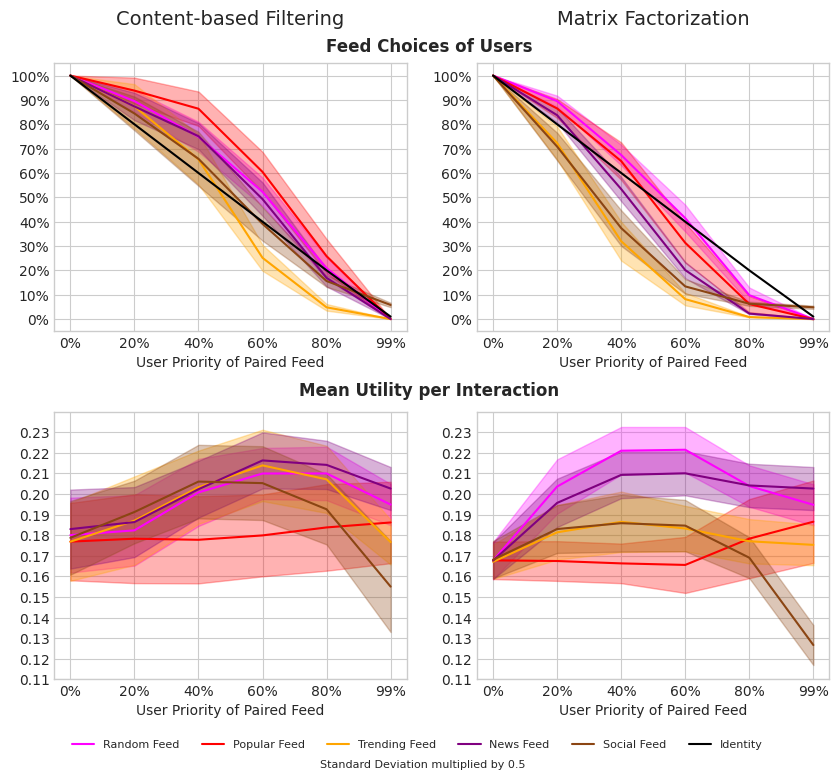

In [25]:
import matplotlib.ticker as ticker
plt.rcParams.update({'font.size': 10})
fig, axes = plt.subplots(2, 2, figsize=(10, 8))  # 2 rows, 2 columns, (width x height)
fig.subplots_adjust(hspace=0.3, wspace=0.2)

mult_sd = 0.5
row=-1
for metric_name, v in metrics_1.items():
    row+=1
    
    upper_ylim = -10.0
    lower_ylim = 10.0
    for feed in feed_names + (['identity'] if metric_name == 'choices' else []):
        col=-1
        for mo in model_keys:
            col+=1
            ax = axes[row, col]
            if feed != 'identity':
                x_axis_labels = all_results_to_readable[feed]
                x_axis = [x_axis_labels[r] for r in list(v[feed][mo].keys())]
                y_axis = np.array(list(v[feed][mo].values()))
                values = gaussian_filter1d(y_axis.mean(axis=1), sigma=plotting_sigma)
                ax.plot(x_axis, values, label=feed_names_to_readable[feed], color=feed_colors[feed])

                std = y_axis.std(axis=1)
                mtus = np.arange(len(std))
                low = values - mult_sd * std
                high = values + mult_sd * std
                low = gaussian_filter1d(low, sigma=plotting_sigma)
                high = gaussian_filter1d(high, sigma=plotting_sigma)
                ax.fill_between(mtus, low, high, color=feed_colors[feed], alpha=0.3)

                upper_ylim = max(high.max(), upper_ylim)
                lower_ylim = min(low.min(), lower_ylim)
            else:
                identity = np.append(np.arange(1.0, 0.0, -1/5), 0.01)
                ax.plot(x_axis, identity, label='Identity', color="k")

    upper_ylim = np.round(upper_ylim, 2) + 0.01
    lower_ylim = np.round(lower_ylim, 2) - 0.01
    col=-1
    for mo in model_keys:
        col+=1
        ax = axes[row, col]
        ax.set_ylim((lower_ylim, upper_ylim))
        ax.set_yticks(np.arange(lower_ylim, upper_ylim, np.round((upper_ylim-lower_ylim)/24, 2)))
        if metric_name == 'choices':
            ax.set_ylim((-0.05, 1.05))
            ax.set_yticks(np.arange(0, 1.05, 0.1))
            ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x*100)}%"))
        ax.set_xlabel("User Priority of Paired Feed")
    fig.text(
        x=0.5,
        y=0.89 - row*0.43,
        s=metric_names_to_readable[metric_name],
        ha='center',
        va='bottom', 
        fontsize=12, 
        fontweight='bold',
    )
for ax, col in zip(axes[0], model_keys):
    ax.set_title(model_to_readable[col], fontsize=14, pad=28.0)

ax.legend(loc='lower center', bbox_to_anchor=(-0.17, -1.6), ncol=6, fontsize=8)
plt.text(x=-1.1, y=0.067, s="Standard Deviation multiplied by 0.5", ha='center', fontsize=8)
plt.show()

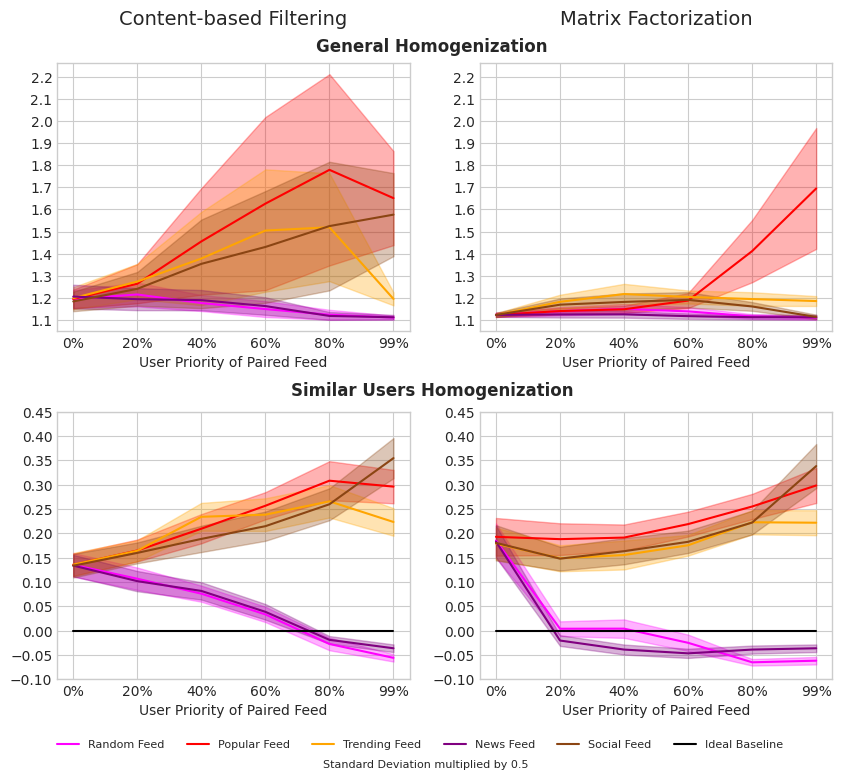

In [34]:
plt.rcParams.update({'font.size': 10})
fig, axes = plt.subplots(2, 2, figsize=(10, 8))  # 2 rows, 2 columns, (width x height)
fig.subplots_adjust(hspace=0.3, wspace=0.2)

mult_sd = 0.5
row=-1
for metric_name, v in metrics_2.items():
    row+=1
    
    upper_ylim = -10.0
    lower_ylim = 10.0
    for feed in feed_names + (['base'] if metric_name == 'sim_homog' else []):
        col=-1
        for mo in model_keys:
            col+=1
            ax = axes[row, col]
            if feed != 'base':
                x_axis_labels = all_results_to_readable[feed]
                x_axis = [x_axis_labels[r] for r in list(v[feed][mo].keys())]
                y_axis = np.array(list(v[feed][mo].values()))[:,:,-1]
                values = gaussian_filter1d(y_axis.mean(axis=1), sigma=plotting_sigma)
                ax.plot(x_axis, values, label=feed_names_to_readable[feed], color=feed_colors[feed])

                std = y_axis.std(axis=1)
                mtus = np.arange(len(std))
                low = values - mult_sd * std
                high = values + mult_sd * std
                low = gaussian_filter1d(low, sigma=plotting_sigma)
                high = gaussian_filter1d(high, sigma=plotting_sigma)
                ax.fill_between(mtus, low, high, color=feed_colors[feed], alpha=0.3)

                upper_ylim = max(high.max(), upper_ylim)
                lower_ylim = min(low.min(), lower_ylim)
            else:
                base = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
                ax.plot(x_axis, base, label='Ideal Baseline', color="k")

    upper_ylim = np.round(upper_ylim, 2) + 0.05
    lower_ylim = np.round(lower_ylim, 2) - 0.05
    col=-1
    for mo in model_keys:
        col+=1
        ax = axes[row, col]
        ax.set_ylim((lower_ylim, upper_ylim))
        ax.set_yticks(np.arange(lower_ylim+0.05, upper_ylim, np.round((upper_ylim-lower_ylim)/12, 2)))
        if metric_name == "sim_homog":
            ax.set_ylim((-0.1, 0.45))
            ax.set_yticks(np.arange(-0.1, 0.5, 0.05))
        ax.set_xlabel("User Priority of Paired Feed")
    fig.text(
        x=0.5,
        y=0.89 - row*0.43,
        s=metric_names_to_readable[metric_name],
        ha='center',
        va='bottom', 
        fontsize=12, 
        fontweight='bold',
    )
for ax, col in zip(axes[0], model_keys):
    ax.set_title(model_to_readable[col], fontsize=14, pad=28.0)

plt.legend(loc='lower center', bbox_to_anchor=(-0.17, -0.3), ncol=6, fontsize=8)
plt.text(x=-1.1, y=-0.28, s="Standard Deviation multiplied by 0.5", ha='center', fontsize=8)
plt.show()

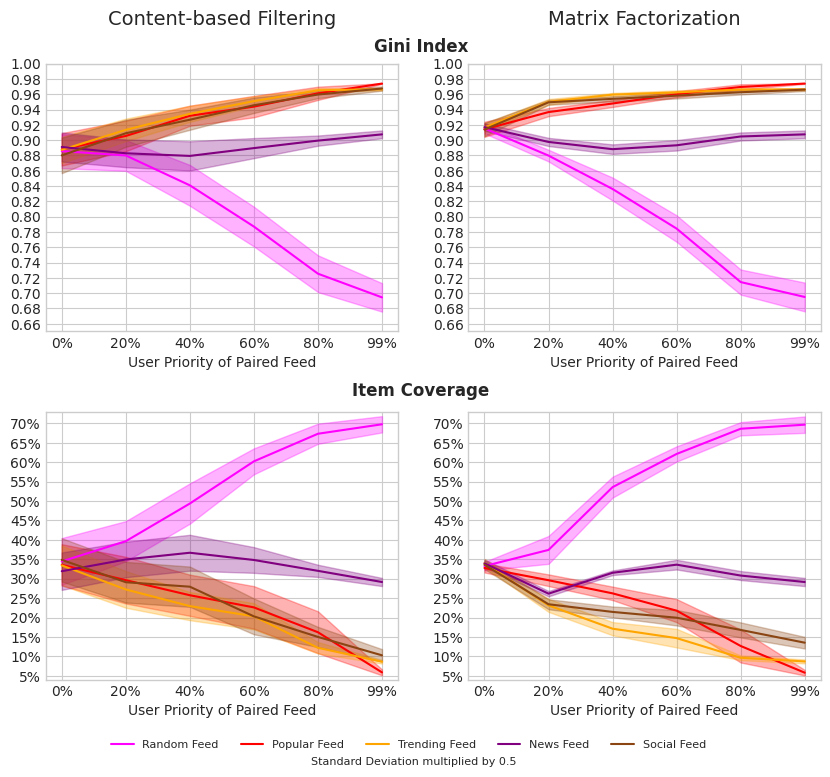

In [27]:
plt.rcParams.update({'font.size': 10})
fig, axes = plt.subplots(2, 2, figsize=(10, 8))  # 2 rows, 2 columns, (width x height)
fig.subplots_adjust(hspace=0.3, wspace=0.2)

mult_sd = 0.5
row=-1
for metric_name, v in metrics_3.items():
    row+=1
    
    upper_ylim = -10.0
    lower_ylim = 10.0
    for feed in feed_names + (['base'] if metric_name == 'sim_homog' else []):
        col=-1
        for mo in model_keys:
            col+=1
            ax = axes[row, col]
            if feed != 'base':
                x_axis_labels = all_results_to_readable[feed]
                x_axis = [x_axis_labels[r] for r in list(v[feed][mo].keys())]
                y_axis = np.array(list(v[feed][mo].values()))[:,:,-1]
                values = gaussian_filter1d(y_axis.mean(axis=1), sigma=plotting_sigma)
                ax.plot(x_axis, values, label=feed_names_to_readable[feed], color=feed_colors[feed])

                std = y_axis.std(axis=1)
                mtus = np.arange(len(std))
                low = values - mult_sd * std
                high = values + mult_sd * std
                low = gaussian_filter1d(low, sigma=plotting_sigma)
                high = gaussian_filter1d(high, sigma=plotting_sigma)
                ax.fill_between(mtus, low, high, color=feed_colors[feed], alpha=0.3)

                upper_ylim = max(high.max(), upper_ylim)
                lower_ylim = min(low.min(), lower_ylim)
            else:
                base = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
                ax.plot(x_axis, base, label='Ideal Baseline', color="k")

    upper_ylim = np.round(upper_ylim, 2) + 0.03
    lower_ylim = np.round(lower_ylim, 2) - 0.03
    col=-1
    for mo in model_keys:
        col+=1
        ax = axes[row, col]
        ax.set_ylim((lower_ylim, upper_ylim))
        ax.set_yticks(np.arange(0.66, 1.01, 0.02))
        if metric_name == 'cover':
            ax.set_yticks(np.arange(0.00, 0.75, 0.05))
            ax.set_ylim((0.04, 0.73))
            ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x*100)}%"))
        ax.set_xlabel("User Priority of Paired Feed")
    fig.text(
        x=0.5,
        y=0.89 - row*0.43,
        s=metric_names_to_readable[metric_name],
        ha='center',
        va='bottom', 
        fontsize=12, 
        fontweight='bold',
    )
for ax, col in zip(axes[0], model_keys):
    ax.set_title(model_to_readable[col], fontsize=14, pad=28.0)

plt.legend(loc='lower center', bbox_to_anchor=(-0.17, -0.3), ncol=6, fontsize=8)
plt.text(x=-1.1, y=-0.18, s="Standard Deviation multiplied by 0.5", ha='center', fontsize=8)
plt.show()

In [28]:
all_rs_util = dict()
all_rs_util_share = dict()
all_rs_influence = dict()
for feed in feed_names:
    rs_util = dict()
    rs_util_share = dict()
    rs_influence = dict()
    for mo in model_keys:
        rs_util[mo] = dict()
        rs_util_share[mo] = dict()
        rs_influence[mo] = dict()
        r0_fo = list(all_utilities[feed][mo].keys())[0]
        for fo in all_utilities[feed][mo].keys():
            rs_util[mo][fo] = []
            rs_util_share[mo][fo] = []
            rs_influence[mo][fo] = []
            for i in range(all_utilities[feed][mo][fo].shape[0]):
                re = []
                re2 = []
                re3 = []
                only_rs_utilities_mask = (all_decisions[feed][mo][fo][i] == 0).astype(float)
                number_of_rs_choices = only_rs_utilities_mask.sum(axis=1)
                utility_from_rs = (all_utilities[feed][mo][fo][i]*only_rs_utilities_mask).sum(axis=1) / number_of_rs_choices
                share_from_rs = (all_utilities[feed][mo][fo][i]*only_rs_utilities_mask).sum(axis=1) / all_utilities[feed][mo][fo][i].sum(axis=1) #* (number_of_rs_choices / only_rs_utilities_mask.shape[1])
                sorted_utilities = np.sort(all_utilities[feed][mo][r0_fo][i], axis=1)[:,::-1]
                top_utils_mean = np.array([
                    np.mean(sorted_utilities[u, :number_of_rs_choices.astype(int)[u]])
                    for u in range(sorted_utilities.shape[0])
                ])
                influence = utility_from_rs - top_utils_mean
                re.append(np.nanmean(utility_from_rs))
                re2.append(np.nanmean(share_from_rs))
                re3.append(np.nanmean(influence))
                rs_util[mo][fo].append(re)
                rs_util_share[mo][fo].append(re2)
                rs_influence[mo][fo].append(re3)
            rs_util[mo][fo] = np.array(rs_util[mo][fo])
            rs_util_share[mo][fo] = np.array(rs_util_share[mo][fo])
            rs_influence[mo][fo] = np.array(rs_influence[mo][fo])
    all_rs_util[feed] = rs_util
    all_rs_util_share[feed] = rs_util_share
    all_rs_influence[feed] = rs_influence

In [29]:
metrics_4 = {
    'rs_util': all_rs_util,
    #'rs_util_share': all_rs_util_share,
    'rs_influence': all_rs_influence,
}

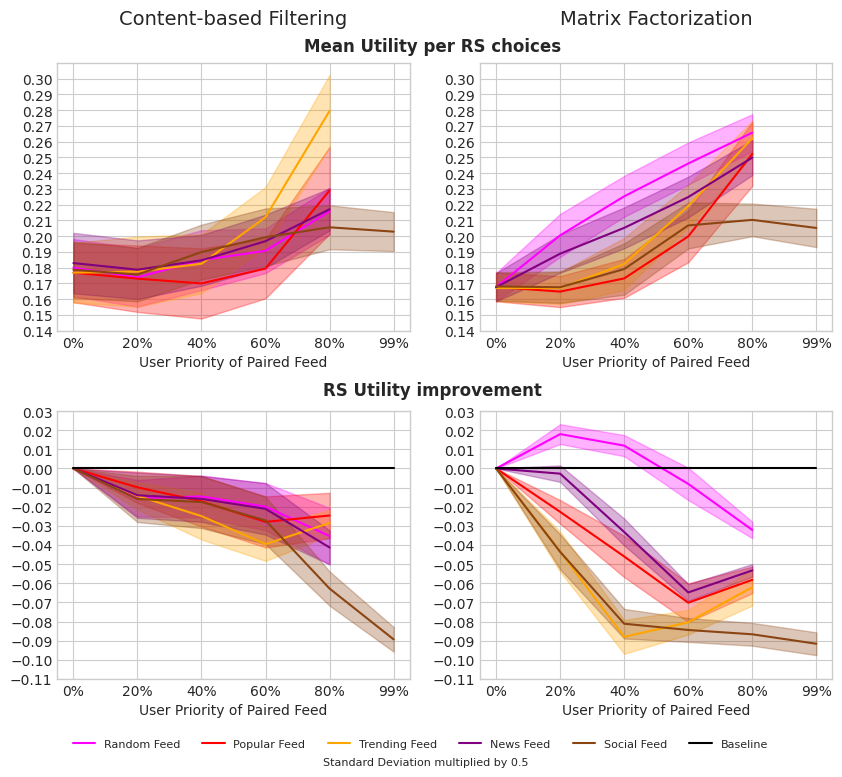

In [30]:
plt.rcParams.update({'font.size': 10})
fig, axes = plt.subplots(2, 2, figsize=(10, 8))  # 2 rows, 2 columns, (width x height)
fig.subplots_adjust(hspace=0.3, wspace=0.2)

mult_sd = 0.5
row=-1
for metric_name, v in metrics_4.items():
    row+=1
    upper_ylim = -10.0
    lower_ylim = 10.0
    for feed in feed_names + (['base'] if metric_name == 'rs_influence' else []):
        col=-1
        for mo in model_keys:
            col+=1
            ax = axes[row, col]
            if feed != 'base':
                x_axis_labels = all_results_to_readable[feed]
                x_axis = [x_axis_labels[r] for r in list(v[feed][mo].keys())]
                y_axis = np.array(list(v[feed][mo].values()))[:,:,-1]
                values = gaussian_filter1d(y_axis.mean(axis=1), sigma=plotting_sigma)
                ax.plot(x_axis, values, label=feed_names_to_readable[feed], color=feed_colors[feed])

                std = y_axis.std(axis=1)
                mtus = np.arange(len(std))
                low = values - mult_sd * std
                high = values + mult_sd * std
                low = gaussian_filter1d(low, sigma=plotting_sigma)
                high = gaussian_filter1d(high, sigma=plotting_sigma)
                ax.fill_between(mtus, low, high, color=feed_colors[feed], alpha=0.3)

                upper_ylim = max(np.nanmax(high), upper_ylim)
                lower_ylim = min(np.nanmin(low), lower_ylim)
            else:
                base = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
                ax.plot(x_axis, base, label='Baseline', color="k")

    upper_ylim = np.round(upper_ylim, 2) + 0.01
    lower_ylim = np.round(lower_ylim, 2) - 0.01
    col=-1
    for mo in model_keys:
        col+=1
        ax = axes[row, col]
        ax.set_ylim((lower_ylim, upper_ylim))
        ax.set_yticks(np.arange(lower_ylim, upper_ylim, np.round((upper_ylim-lower_ylim)/12, 2)))
        if metric_name == 'cover':
            ax.set_yticks(np.arange(0.00, 0.75, 0.1))
            ax.set_ylim((0.04, 0.73))
            ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x*100)}%"))
        ax.set_xlabel("User Priority of Paired Feed")
    fig.text(
        x=0.5,
        y=0.89 - row*0.43,
        s=metric_names_to_readable[metric_name],
        ha='center',
        va='bottom', 
        fontsize=12, 
        fontweight='bold',
    )
for ax, col in zip(axes[0], model_keys):
    ax.set_title(model_to_readable[col], fontsize=14, pad=28.0)

plt.legend(loc='lower center', bbox_to_anchor=(-0.17, -0.3), ncol=6, fontsize=8)
plt.text(x=-1.1, y=-0.155, s="Standard Deviation multiplied by 0.5", ha='center', fontsize=8)
plt.show()

In [31]:
metrics_5 = {
    'inter': all_inter_user_div,
    'intra': all_intra_user_div,
}

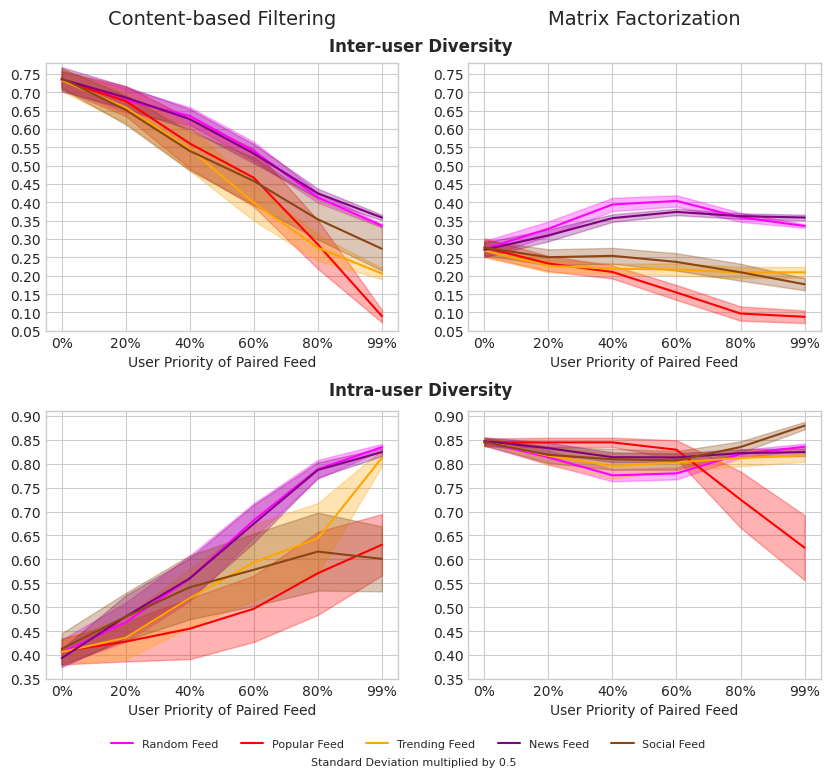

In [32]:
plt.rcParams.update({'font.size': 10})
fig, axes = plt.subplots(2, 2, figsize=(10, 8))  # 2 rows, 2 columns, (width x height)
fig.subplots_adjust(hspace=0.3, wspace=0.2)

mult_sd = 0.5
row=-1
for metric_name, v in metrics_5.items():
    row+=1
    upper_ylim = -10.0
    lower_ylim = 10.0
    for feed in feed_names + (['base'] if metric_name == 'rs_influence' else []):
        col=-1
        for mo in model_keys:
            col+=1
            ax = axes[row, col]
            if feed != 'base':
                x_axis_labels = all_results_to_readable[feed]
                x_axis = [x_axis_labels[r] for r in list(v[feed][mo].keys())]
                y_axis = np.array(list(v[feed][mo].values()))[:,:,-1]
                values = gaussian_filter1d(y_axis.mean(axis=1), sigma=plotting_sigma)
                ax.plot(x_axis, values, label=feed_names_to_readable[feed], color=feed_colors[feed])

                std = y_axis.std(axis=1)
                mtus = np.arange(len(std))
                low = values - mult_sd * std
                high = values + mult_sd * std
                low = gaussian_filter1d(low, sigma=plotting_sigma)
                high = gaussian_filter1d(high, sigma=plotting_sigma)
                ax.fill_between(mtus, low, high, color=feed_colors[feed], alpha=0.3)

                upper_ylim = max(np.nanmax(high), upper_ylim)
                lower_ylim = min(np.nanmin(low), lower_ylim)
            else:
                base = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
                ax.plot(x_axis, base, label='Baseline', color="k")

    upper_ylim = np.round(upper_ylim, 2) + 0.02
    lower_ylim = np.round(lower_ylim, 2) - 0.02
    col=-1
    for mo in model_keys:
        col+=1
        ax = axes[row, col]
        ax.set_ylim((lower_ylim, upper_ylim))
        ax.set_yticks(np.arange(lower_ylim, upper_ylim, np.round((upper_ylim-lower_ylim)/12, 2)))
        if metric_name == 'inter':
            ax.set_yticks(np.arange(0.05, 0.8, 0.05))
            ax.set_ylim((0.05, 0.78))
        ax.set_xlabel("User Priority of Paired Feed")
    fig.text(
        x=0.5,
        y=0.89 - row*0.43,
        s=metric_names_to_readable[metric_name],
        ha='center',
        va='bottom', 
        fontsize=12, 
        fontweight='bold',
    )
for ax, col in zip(axes[0], model_keys):
    ax.set_title(model_to_readable[col], fontsize=14, pad=28.0)

plt.legend(loc='lower center', bbox_to_anchor=(-0.17, -0.3), ncol=6, fontsize=8)
plt.text(x=-1.1, y=0.17, s="Standard Deviation multiplied by 0.5", ha='center', fontsize=8)
plt.show()